In [ ]:
!pip install vaderSentiment wordcloud imbalanced-learn -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ──
import pandas as pd    # Think of this as "Excel for Python"
                       # It lets you work with tables (rows & columns)


import numpy as np     # Math library for arrays and numbers


# ── Text Processing ──
import re              # "Regular Expressions" — pattern matching for text


import nltk            # "Natural Language Toolkit" — classic NLP library
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Machine Learning ──
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from imblearn.over_sampling import SMOTE

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Sentiment Analysis ──
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
# ── Load the two CSV files ──
# pd.read_csv() reads a CSV file and creates a DataFrame (table)
df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')

# Let's see how many articles are in each file
print("Fake.csv:")
print(f"   Rows: {df_fake.shape[0]}")       # .shape[0] = number of rows
print(f"   Columns: {df_fake.shape[1]}")     # .shape[1] = number of columns
print(f"   Column names: {df_fake.columns.tolist()}")  # What columns exist
print()
print("True.csv:")
print(f"   Rows: {df_true.shape[0]}")
print(f"   Columns: {df_true.shape[1]}")
print(f"   Column names: {df_true.columns.tolist()}")

Fake.csv:
   Rows: 25401
   Columns: 4
   Column names: ['title', 'text', 'subject', 'date']

True.csv:
   Rows: 21417
   Columns: 4
   Column names: ['title', 'text', 'subject', 'date']


In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 4: Add labels and combine into one DataFrame
# ══════════════════════════════════════════════════════════

# ── Add a "label" column to each DataFrame ──
# The original files don't have labels — we know which is which
# because of the FILE NAME (Fake.csv vs True.csv)
# We need to add this information as a column the model can learn from

df_fake['label'] = 1   # 1 = FAKE news
df_true['label'] = 0   # 0 = REAL news
# This adds a new column called "label" to every row
# Every row in df_fake gets label=1, every row in df_true gets label=0

# ── Combine both DataFrames into one ──
df = pd.concat([df_fake, df_true], ignore_index=True)
# pd.concat() stacks two tables on top of each other:
#
#   df_fake (23,481 rows)     →  row 0 to 23,480
#   +                              +
#   df_true (21,417 rows)     →  row 23,481 to 44,897
#   =                              =
#   df (44,898 rows total)    →  row 0 to 44,897
#
# ignore_index=True resets the row numbers to 0,1,2,3...
# Without it, you'd have duplicate row numbers

# ── Shuffle the data ──
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# WHY SHUFFLE?
# Right now the data is ordered: all fake first, then all real.
# If we train on the first 80%, the model would see mostly fake articles
# and very few real ones — it would learn a biased pattern.
# Shuffling mixes them randomly so fake and real are evenly spread.
#
# frac=1       → shuffle 100% of the data (all rows)
# random_state=42 → use this "seed" so the shuffle is the same every time
#                    (makes your results reproducible — important for science!)
# .reset_index(drop=True) → renumber rows 0,1,2,3... after shuffling
#                           drop=True means "don't keep the old row numbers"

print(f"Combined dataset: {df.shape[0]} total articles")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
# value_counts() counts how many rows have each unique value
# Should show: 1 (fake) = ~23,481 and 0 (real) = ~21,417

print(f"\nAs percentages:")
print(df['label'].value_counts(normalize=True).round(4) * 100)
# normalize=True shows percentages instead of counts

Combined dataset: 46818 total articles

Label distribution:
label
1    25401
0    21417
Name: count, dtype: int64

As percentages:
label
1    54.25
0    45.75
Name: proportion, dtype: float64


In [ ]:
print("=== First 5 rows of the dataset ===")
df.head()

=== First 5 rows of the dataset ===


,title,text,subject,date,label
0,Egyptian air force says strikes arms convoy at...,CAIRO (Reuters) - The Egyptian military said o...,worldnews,"October 23, 2017",0
1,Judge orders search of new Clinton emails for ...,(Reuters) - A U.S. judge ordered the State Dep...,politicsNews,"August 25, 2016",0
2,U.S. will stand be steadfast ally to Britain a...,LONDON (Reuters) - The United States will stan...,worldnews,"September 14, 2017",0
3,Conservative ‘Christians’ Panic After Ted Cru...,According to Ted Cruz and many of his staunche...,News,"May 4, 2016",1
4,Italian left's efforts to stop migrants may ba...,ROME (Reuters) - A deal with Libya that has sl...,worldnews,"November 22, 2017",0


In [ ]:
# ── 1. Data types and memory usage ──
print("=== Data Types ===")
print(df.dtypes)
# object = text/string
# int64  = integer number
print()

# ── 2. Check for missing values ──
print("=== Missing Values (NaN) ===")
print(df.isnull().sum())
# .isnull() marks each cell as True (missing) or False (has data)
# .sum() counts how many True values per column
# Missing values can crash your model — we need to handle them
print()

# ── 3. What subjects/categories exist? ──
print("=== News Subjects ===")
print(df['subject'].value_counts())
# This shows what types of news are in the dataset
# e.g., "politicsNews", "worldnews", "News", "politics", "left-news"
print()

=== Data Types ===
title      object
text       object
subject    object
date       object
label       int64
dtype: object

=== Missing Values (NaN) ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== News Subjects ===
subject
politicsNews       11272
News               10970
worldnews          10145
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64



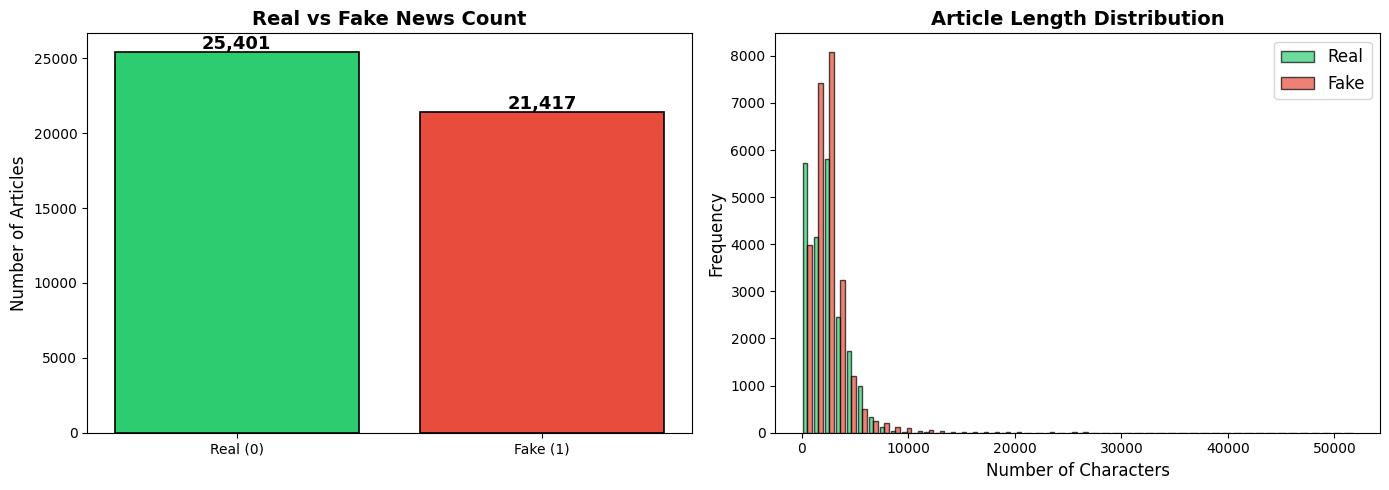


Article Length Statistics:
         count    mean     std  min     25%     50%     75%      max
label                                                               
0      21417.0  2383.0  1685.0  1.0   914.0  2222.0  3237.0  29781.0
1      25401.0  2553.0  2451.0  1.0  1502.0  2188.0  3032.0  51794.0


In [ ]:
# Create a figure with 2 charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(rows, columns, figsize=(width, height))
# 1 row, 2 columns = 2 charts side by side
# figsize=(14, 5) = 14 inches wide, 5 inches tall
# Returns:
#   fig  = the overall figure (canvas)
#   axes = list of 2 axes (individual chart areas) → axes[0] and axes[1]

# ── Chart 1: Bar chart of Real vs Fake count ──
label_counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']   # Green for real, Red for fake

bars = axes[0].bar(
    ['Real (0)', 'Fake (1)'],     # X-axis labels (what goes under each bar)
    label_counts.values,           # Bar heights (the counts)
    color=colors,                  # Bar colors
    edgecolor='black',             # Black border around bars
    linewidth=1.2,                 # Border thickness
)
axes[0].set_title('Real vs Fake News Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Articles', fontsize=12)

# Add the exact number on top of each bar
for i, count in enumerate(label_counts.values):
    # enumerate() gives both the index (i=0,1) and the value (count)
    axes[0].text(
        i,              # X position (0 for first bar, 1 for second)
        count + 200,    # Y position (slightly above the bar top)
        f'{count:,}',   # Text to show (f-string with comma formatting)
        ha='center',    # Horizontal alignment: center
        fontsize=13,
        fontweight='bold',
    )

# ── Chart 2: Article length distribution ──
# Let's see if fake and real articles are different lengths
df['text_length'] = df['text'].astype(str).apply(len)
# .astype(str)  → convert to string (in case any NaN values exist)
# .apply(len)   → apply the len() function to each row (counts characters)
# Result: new column 'text_length' with character count per article

axes[1].hist(
    [
        df[df['label'] == 0]['text_length'],  # Real article lengths
        df[df['label'] == 1]['text_length'],  # Fake article lengths
    ],
    bins=50,              # Split the range into 50 bars
    color=colors,         # Green and red
    label=['Real', 'Fake'],
    alpha=0.7,            # 70% opaque (so overlapping bars are visible)
    edgecolor='black',
)
axes[1].set_title('Article Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Characters', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend(fontsize=12)   # Show the green=Real, red=Fake legend

plt.tight_layout()   # Automatically adjust spacing so nothing overlaps
plt.show()           # Display the charts

# ── Print summary statistics ──
print("\nArticle Length Statistics:")
print(df.groupby('label')['text_length'].describe().round(0))
# .groupby('label')    → split data by label (0 and 1)
# ['text_length']      → look at the text_length column
# .describe()          → show count, mean, std, min, 25%, 50%, 75%, max

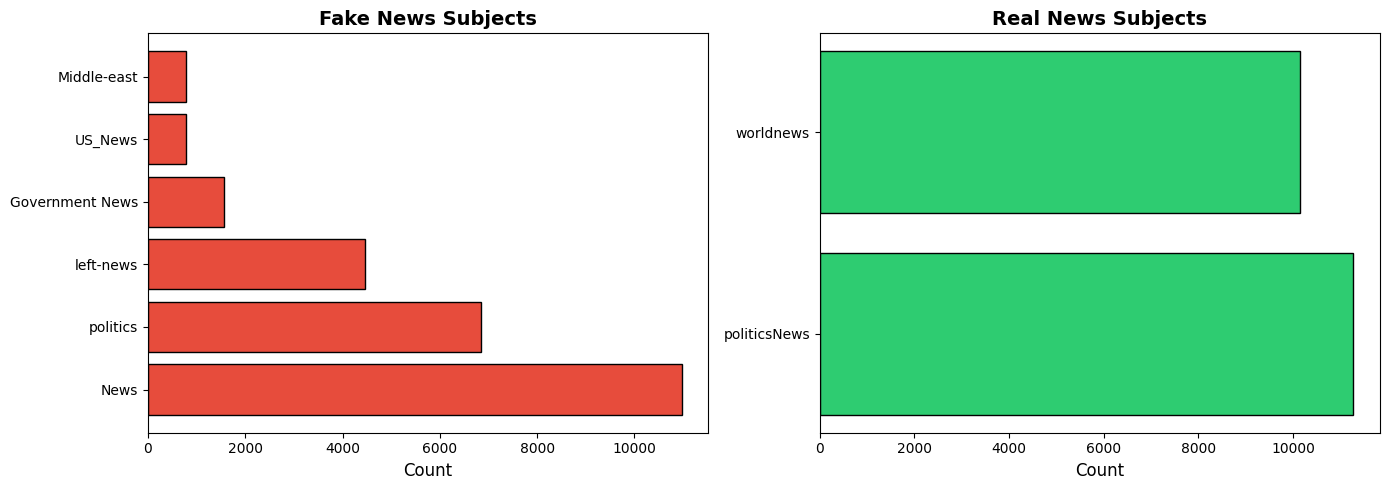

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count subjects for fake news
fake_subjects = df[df['label'] == 1]['subject'].value_counts()
axes[0].barh(
    fake_subjects.index,    # Y-axis labels (subject names)
    fake_subjects.values,   # Bar lengths (counts)
    color='#e74c3c',
    edgecolor='black',
)
axes[0].set_title('Fake News Subjects', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
# .barh() = horizontal bar chart (easier to read long labels)

# Count subjects for real news
real_subjects = df[df['label'] == 0]['subject'].value_counts()
axes[1].barh(
    real_subjects.index,
    real_subjects.values,
    color='#2ecc71',
    edgecolor='black',
)
axes[1].set_title('Real News Subjects', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Initialize tools we need
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# set() converts the list to a set for FAST lookups
# Checking "is this word in the set?" is instant with sets
# but slow with lists (has to check every element)

# Let's see what stopwords look like:
print(f"Total English stopwords: {len(stop_words)}")
print(f"Examples: {list(stop_words)[:20]}")
print()


def clean_text(text):
    """
    Takes a raw article/post and returns a cleaned version.

    What this function does step by step:
    1. Handles missing/invalid input
    2. Removes URLs (http links)
    3. Removes @mentions
    4. Removes hashtags
    5. Removes HTML tags
    6. Removes numbers and special characters
    7. Converts to lowercase
    8. Removes stopwords (common meaningless words)
    9. Lemmatizes (converts words to base form)
    """

    # ── Step 1: Handle bad input ──
    if not isinstance(text, str):
        return ""
    # isinstance(text, str) checks: "is text actually a string?"
    # If someone passed None, NaN, or a number, we return empty string
    # Without this check, the function would CRASH on NaN values

    # ── Step 2: Remove URLs ──
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # re.sub(pattern, replacement, string)
    #   → finds all matches of "pattern" in "string"
    #   → replaces them with "replacement" (empty string = delete)
    #
    # Breaking down the pattern: r'https?://\S+|www\.\S+'
    #   r'...'    → raw string (treats backslash \ literally)
    #   https?    → "http" followed by optional "s" (matches http AND https)
    #   ://       → literal characters "://"
    #   \S+       → one or more NON-whitespace characters (the rest of the URL)
    #   |         → OR (match either the left pattern or the right)
    #   www\.     → literal "www." (the \ escapes the dot)
    #   \S+       → rest of the URL
    #
    # Example: "Visit https://fake.com now" → "Visit  now"

    # ── Step 3: Remove @mentions ──
    text = re.sub(r'@\w+', '', text)
    #   @     → literal "@"
    #   \w+   → one or more "word characters" (letters, digits, underscore)
    # Example: "Hey @john123 check this" → "Hey  check this"

    # ── Step 4: Remove hashtags ──
    text = re.sub(r'#\w+', '', text)
    # Example: "#Breaking news #fakenews" → " news "

    # ── Step 5: Remove HTML tags ──
    text = re.sub(r'<.*?>', '', text)
    #   <     → literal "<"
    #   .*?   → any characters (as FEW as possible — this is "non-greedy")
    #   >     → literal ">"
    # Example: "<p>Hello <b>World</b></p>" → "Hello World"
    #
    # Why .*? (non-greedy) instead of .* (greedy)?
    #   Greedy .*  on "<p>Hello</p>" would match "<p>Hello</p>" (everything)
    #   Non-greedy .*? matches "<p>" then "</p>" separately (what we want)

    # ── Step 6: Remove special characters and numbers ──
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    #   [^...]   → NOT these characters (^ inside brackets means "NOT")
    #   a-zA-Z   → all lowercase and uppercase letters
    #   \s       → whitespace (spaces, tabs, newlines)
    #   So this KEEPS only letters and spaces, REMOVES everything else
    # Example: "It's 100% fake!!!" → "Its  fake"

    # ── Step 7: Convert to lowercase ���─
    text = text.lower()
    # "BREAKING NEWS" → "breaking news"
    # Why? So the model treats "Fake" and "fake" as the same word

    # ── Step 8: Remove stopwords ──
    words = text.split()
    # .split() breaks a string into a list of words (splits on spaces)
    # "hello world" → ["hello", "world"]

    words = [word for word in words if word not in stop_words]
    # This is a LIST COMPREHENSION — a compact way to filter a list
    # Long form equivalent:
    #   filtered = []
    #   for word in words:
    #       if word not in stop_words:
    #           filtered.append(word)
    #   words = filtered
    #
    # It removes: "the", "is", "at", "which", "on", "a", "an", "in", etc.
    # These words appear everywhere and don't help distinguish fake from real

    # ── Step 9: Lemmatize ──
    words = [lemmatizer.lemmatize(word) for word in words]
    # Lemmatization converts words to their base/dictionary form:
    #   "dogs"      → "dog"
    #   "running"   → "running" (verb lemmatization is limited without POS tagging)
    #   "better"    → "better"
    #   "countries"  → "country"
    #   "studies"   → "study"

    # ── Join back into a single string ──
    return ' '.join(words)
    # ' '.join(["hello", "world"]) → "hello world"
    # Opposite of .split()


# ══════════════════════════════════════════════════════════
# TEST THE FUNCTION
# ══════════════════════════════════════════════════════════

test_cases = [
    "BREAKING!!! Check https://fake.com @user #exposed — This is 100% a LIE!!!",
    "The president announced new healthcare policies on Monday, January 5th.",
    "<p>Read more at <a href='link'>our website</a></p>",
    None,
    "",
]

print("=== Testing clean_text() ===\n")
for text in test_cases:
    print(f"  INPUT:  {text}")
    print(f"  OUTPUT: '{clean_text(text)}'")
    print()

Total English stopwords: 198
Examples: ["we'd", 'myself', "she'd", 'theirs', 'mightn', 'up', 'the', "she'll", 'nor', 'all', 'am', "he'd", 'hasn', 'too', 'can', 'further', 'on', 'off', 'ain', 'now']

=== Testing clean_text() ===

  INPUT:  BREAKING!!! Check https://fake.com @user #exposed — This is 100% a LIE!!!
  OUTPUT: 'breaking check lie'

  INPUT:  The president announced new healthcare policies on Monday, January 5th.
  OUTPUT: 'president announced new healthcare policy monday january th'

  INPUT:  <p>Read more at <a href='link'>our website</a></p>
  OUTPUT: 'read website'

  INPUT:  None
  OUTPUT: ''

  INPUT:  
  OUTPUT: ''



In [ ]:
# First, handle missing values
print(f"Missing values in 'text' column: {df['text'].isnull().sum()}")
df = df.dropna(subset=['text'])
# .dropna(subset=['text']) removes rows where the 'text' column is NaN
# subset=['text'] means "only look at the 'text' column for NaN"
# Without subset, it would drop rows where ANY column is NaN

print(f"Rows after dropping NaN: {df.shape[0]}")

# Now apply clean_text to every article
# This might take 30-60 seconds for ~44,000 articles
print("\n⏳ Cleaning all articles... (this takes about 30-60 seconds)")

df['cleaned_text'] = df['text'].apply(clean_text)
# .apply(clean_text) runs our clean_text function on EVERY row
# It creates a NEW column called 'cleaned_text' with the results
#
# What happens internally:
#   Row 0: clean_text("WASHINGTON (Reuters) - The U.S. ...") → "washington reuters u ..."
#   Row 1: clean_text("Donald Trump just ...") → "donald trump just ..."
#   Row 2: clean_text(...) → ...
#   ... 44,000 more times

# Remove any rows where cleaning produced empty text
before = df.shape[0]
df = df[df['cleaned_text'].str.strip() != '']
# df['cleaned_text'].str.strip() → remove leading/trailing spaces
# != '' → keep only rows that are NOT empty
after = df.shape[0]
print(f"Removed {before - after} empty rows after cleaning")

print(f"Final dataset size: {df.shape[0]} articles")

# ── Show before vs after ──
print("\n=== Before vs After Cleaning ===")
for i in range(3):
    print(f"\n--- Article {i+1} (Label: {'FAKE' if df['label'].iloc[i] == 1 else 'REAL'}) ---")
    print(f"BEFORE: {df['text'].iloc[i][:200]}...")
    print(f"AFTER:  {df['cleaned_text'].iloc[i][:200]}...")

print("\nText preprocessing complete!")

Missing values in 'text' column: 0
Rows after dropping NaN: 46818

⏳ Cleaning all articles... (this takes about 30-60 seconds)
Removed 716 empty rows after cleaning
Final dataset size: 46102 articles

=== Before vs After Cleaning ===

--- Article 1 (Label: REAL) ---
BEFORE: CAIRO (Reuters) - The Egyptian military said on Monday its air force hit eight four-wheel-drive vehicles carrying arms and explosives at Egypt s western border with Libya, killing the militants on boa...
AFTER:  cairo reuters egyptian military said monday air force hit eight fourwheeldrive vehicle carrying arm explosive egypt western border libya killing militant board military statement gave detail number fa...

--- Article 2 (Label: REAL) ---
BEFORE: (Reuters) - A U.S. judge ordered the State Department on Thursday to release by Sept. 13 any emails it finds between Hillary Clinton and the White House from the week of the 2012 attack in Benghazi, L...
AFTER:  reuters u judge ordered state department thursday releas

Total words in Real news: 4,853,107
Total words in Fake news: 5,821,357


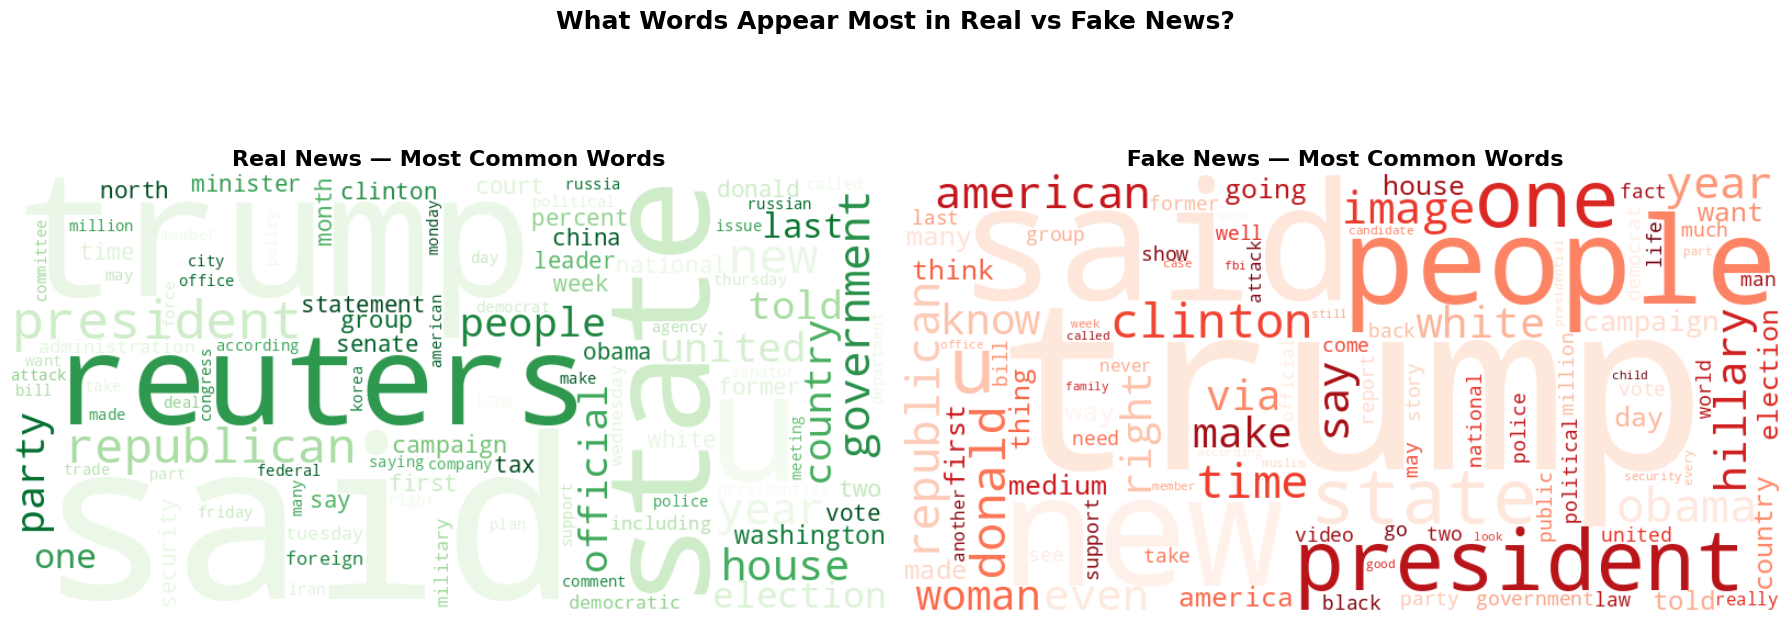


 Things to notice:
   - Real news might have: 'said', 'reuters', 'president', 'official'
   - Fake news might have: 'trump', 'obama', 'hillary', 'video'
   - These patterns help the model learn!


In [ ]:
# ── Combine all text for each category ──
real_text = ' '.join(df[df['label'] == 0]['cleaned_text'])
fake_text = ' '.join(df[df['label'] == 1]['cleaned_text'])
# ' '.join(list_of_strings) combines them into one giant string
# We need one big string because WordCloud counts word frequencies from it
#
# Example: ' '.join(["hello world", "hello there"]) → "hello world hello there"
# Then WordCloud sees: hello=2, world=1, there=1

print(f"Total words in Real news: {len(real_text.split()):,}")
print(f"Total words in Fake news: {len(fake_text.split()):,}")

# ── Create word clouds ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Real news word cloud
wc_real = WordCloud(
    width=800,                  # Image width in pixels
    height=400,                 # Image height in pixels
    background_color='white',   # Background color
    colormap='Greens',          # Color scheme for the words
    max_words=100,              # Show only top 100 most frequent words
    random_state=42,            # Same layout every time
    collocations=False,         # Don't repeat word pairs
).generate(real_text)
# .generate() does all the work:
# 1. Splits the text into words
# 2. Counts how often each word appears
# 3. Assigns bigger font size to more frequent words
# 4. Arranges them into a cloud shape

axes[0].imshow(wc_real, interpolation='bilinear')
# .imshow() displays an image on the chart
# interpolation='bilinear' makes the text look smoother (anti-aliased)
axes[0].set_title('Real News — Most Common Words', fontsize=16, fontweight='bold')
axes[0].axis('off')  # Hide the x and y axis numbers (not meaningful for images)

# Fake news word cloud
wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    random_state=42,
    collocations=False,
).generate(fake_text)

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title(' Fake News — Most Common Words', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.suptitle('What Words Appear Most in Real vs Fake News?',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── TIP: Look at the differences! ──
print("\n Things to notice:")
print("   - Real news might have: 'said', 'reuters', 'president', 'official'")
print("   - Fake news might have: 'trump', 'obama', 'hillary', 'video'")
print("   - These patterns help the model learn!")

In [ ]:
# ═══ WHY DO WE NEED THIS? ═══
# Machine learning models can ONLY work with numbers, not text.
# We need to convert each article from words into a row of numbers.
#
# ═══ WHAT IS TF-IDF? ═══
# TF  = Term Frequency
#       "How often does this word appear in THIS article?"
#       If "trump" appears 5 times in a 100-word article: TF = 5/100 = 0.05
#
# IDF = Inverse Document Frequency
#       "How rare is this word across ALL articles?"
#       If "trump" appears in 10,000 out of 40,000 articles: pretty common → low IDF
#       If "hoax" appears in 200 out of 40,000 articles: very rare → high IDF
#
# TF-IDF = TF × IDF
#       Common words everywhere (like "said") get LOW scores
#       Rare but important words (like "hoax") get HIGH scores
#       This highlights the words that make each article UNIQUE

# ── Step 1: Separate features (X) and labels (y) ──
X = df['cleaned_text']   # What the model will READ (input)
y = df['label']           # What the model will PREDICT (output: 0 or 1)

print(f"Total samples: {len(X):,}")
print(f"Label distribution:")
print(f"  Real (0): {(y == 0).sum():,}")
print(f"  Fake (1): {(y == 1).sum():,}")
print()

# ── Step 2: Split into training and testing sets ──
X_train, X_test, y_train, y_test = train_test_split(
    X,                    # Features (text)
    y,                    # Labels (0 or 1)
    test_size=0.2,        # 20% for testing, 80% for training
    random_state=42,      # Reproducible split
    stratify=y,           # IMPORTANT: keep the same fake/real ratio in both sets
)
# train_test_split returns 4 things:
#   X_train → 80% of the text (for training)
#   X_test  → 20% of the text (for testing — model never sees this during training)
#   y_train → labels for training text
#   y_test  → labels for testing text
#
# WHY SPLIT?
# If you test on the same data you trained on, you're just testing
# the model's MEMORY, not its ability to generalize to new articles.
# It's like studying the exact test questions — you might score 100%
# but you didn't actually learn the subject.
#
# WHY stratify=y?
# If the data is 52% fake and 48% real, both train and test sets
# will ALSO be 52% fake and 48% real. Without stratify, random
# chance might give you a test set that's 60% fake and 40% real,
# which would make your results misleading.

print(f"Training set: {len(X_train):,} articles")
print(f"Testing set:  {len(X_test):,} articles")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTesting label distribution:")
print(y_test.value_counts())

Total samples: 46,102
Label distribution:
  Real (0): 21,416
  Fake (1): 24,686

Training set: 36,881 articles
Testing set:  9,221 articles

Training label distribution:
label
1    19748
0    17133
Name: count, dtype: int64

Testing label distribution:
label
1    4938
0    4283
Name: count, dtype: int64


In [ ]:
# ── Create the vectorizer ──
tfidf = TfidfVectorizer(
    max_features=10000,     # Only keep the 10,000 most important words
                            # (the full vocabulary might be 100,000+ words,
                            # but most rare words appear only once — useless)

    ngram_range=(1, 2),     # Use both single words AND two-word phrases
                            # (1,1) = unigrams only: ["fake", "news"]
                            # (1,2) = unigrams + bigrams: ["fake", "news", "fake news"]
                            # Bigrams capture meaning that single words miss:
                            #   "not" + "true" = useless separately
                            #   "not true" = very meaningful together!

    min_df=2,               # Ignore words appearing in fewer than 2 articles
                            # Words that appear only once are probably typos
                            # or very specific names — not useful patterns

    max_df=0.95,            # Ignore words appearing in more than 95% of articles
                            # Words in almost every article (like "said") don't
                            # help distinguish fake from real
)

# ── Fit on training data, transform both sets ──
print("⏳ Converting text to TF-IDF features...")

X_train_tfidf = tfidf.fit_transform(X_train)
# fit_transform() does TWO things in one call:
#
# 1. FIT (learn):
#    - Scans all training text
#    - Builds a vocabulary of the top 10,000 words
#    - Calculates IDF scores for each word
#    - Stores this knowledge internally
#
# 2. TRANSFORM (convert):
#    - Uses the learned vocabulary to convert each article
#      into a row of 10,000 numbers (one per word)
#    - Each number = the TF-IDF score for that word in that article
#
# Result: a SPARSE MATRIX (most values are 0, because each article
# only contains a small fraction of all 10,000 words)

X_test_tfidf = tfidf.transform(X_test)
# transform() ONLY (no fit!):
# Uses the SAME vocabulary learned from training data
#
# ⚠️ CRITICAL: We NEVER fit on test data!
# If we did, the model would "know" about test data patterns → cheating!
# This is called "data leakage" and it's a common beginner mistake.

print(f"\nTF-IDF conversion complete!")
print(f"\nTraining matrix shape: {X_train_tfidf.shape}")
print(f"  → {X_train_tfidf.shape[0]:,} articles × {X_train_tfidf.shape[1]:,} features")
print(f"\nTesting matrix shape: {X_test_tfidf.shape}")
print(f"  → {X_test_tfidf.shape[0]:,} articles × {X_test_tfidf.shape[1]:,} features")

# ── Show some vocabulary words ──
feature_names = tfidf.get_feature_names_out()
print(f"\nVocabulary size: {len(feature_names):,} words/phrases")
print(f"First 20 words: {feature_names[:20].tolist()}")
print(f"Last 20 words:  {feature_names[-20:].tolist()}")

# ── Show a sample TF-IDF vector ──
print(f"\nSample: Article #0 has {X_train_tfidf[0].nnz} non-zero features out of {X_train_tfidf.shape[1]}")
# .nnz = "number of non-zeros" — most features are 0 for any given article

⏳ Converting text to TF-IDF features...

TF-IDF conversion complete!

Training matrix shape: (36881, 10000)
  → 36,881 articles × 10,000 features

Testing matrix shape: (9221, 10000)
  → 9,221 articles × 10,000 features

Vocabulary size: 10,000 words/phrases
First 20 words: ['aaron', 'abadi', 'abandon', 'abandoned', 'abandoning', 'abbas', 'abbott', 'abc', 'abc news', 'abc week', 'abdel', 'abdullah', 'abe', 'abedin', 'abide', 'ability', 'able', 'able get', 'aboard', 'abolish']
Last 20 words:  ['young people', 'young woman', 'younger', 'youre', 'youth', 'youtube', 'ypg', 'zanupf', 'zarrab', 'zealand', 'zealand first', 'zero', 'zika', 'zika virus', 'zimbabwe', 'zimbabwean', 'zinke', 'zone', 'zuckerberg', 'zuma']

Sample: Article #0 has 289 non-zero features out of 10000


In [ ]:
# ═══ WHAT IS LOGISTIC REGRESSION? ═══
#
# Despite the name, it's a CLASSIFICATION algorithm (predicts categories).
#
# How it works (simplified):
# 1. It assigns a WEIGHT to each of the 10,000 words
#    e.g., "hoax" gets weight +2.5 (suggests fake)
#         "reuters" gets weight -1.8 (suggests real)
#
# 2. For a new article, it:
#    a. Multiplies each word's TF-IDF score × weight
#    b. Adds them all up to get a single number
#    c. Passes that number through a "sigmoid" function
#       to squish it between 0 and 1 (probability)
#
# 3. If probability > 0.5 → predict FAKE
#    If probability ≤ 0.5 → predict REAL

model_lr = LogisticRegression(
    max_iter=1000,              # Maximum training iterations
                                # If the model hasn't converged after 1000
                                # iterations, stop anyway (prevents infinite loops)

    class_weight='balanced',    # Automatically adjust for class imbalance
                                # Our data is ~52% fake, ~48% real (pretty balanced)
                                # But this setting is a good habit — it tells the model:
                                # "mistakes on the minority class cost MORE"
                                # so it pays equal attention to both classes

    random_state=42,            # Reproducible results

    C=1.0,                      # Regularization strength
                                # Lower C = more regularization (simpler model)
                                # Higher C = less regularization (more complex)
                                # 1.0 is the default and usually works fine
)

# ── Train the model ──
print(" Training Logistic Regression...")
model_lr.fit(X_train_tfidf, y_train)
# .fit() is where the LEARNING happens!
# Internally, it:
# 1. Starts with random weights for all 10,000 words
# 2. Makes predictions on training data
# 3. Checks how wrong the predictions are (loss function)
# 4. Adjusts weights to reduce errors (gradient descent)
# 5. Repeats steps 2-4 up to max_iter times
# 6. Returns the final optimized weights

print(" Training complete!")

# ── Make predictions on test data ──
y_pred_lr = model_lr.predict(X_test_tfidf)
# .predict() uses the learned weights on NEW, unseen articles
# Returns an array of 0s and 1s: [0, 1, 1, 0, 1, 0, ...]

# ── Calculate accuracy ──
accuracy_lr = accuracy_score(y_test, y_pred_lr)
# accuracy = (correct predictions) / (total predictions)
# Example: 8,500 correct out of 9,000 → 94.4%

print(f"\n Accuracy: {accuracy_lr:.4f} ({accuracy_lr:.1%})")
# :.4f = show 4 decimal places (0.9444)
# :.1% = show as percentage with 1 decimal (94.4%)

# ── Detailed classification report ──
print("\n" + "="*55)
print("CLASSIFICATION REPORT — Logistic Regression")
print("="*55)
print(classification_report(y_test, y_pred_lr, target_names=['Real', 'Fake']))
# This shows for EACH class:
#
# PRECISION: "When the model says FAKE, how often is it right?"
#   precision = true positives / (true positives + false positives)
#   High precision = few false alarms
#
# RECALL: "Of all actual FAKE articles, how many did the model catch?"
#   recall = true positives / (true positives + false negatives)
#   High recall = few missed fakes
#
# F1-SCORE: Harmonic mean of precision and recall
#   f1 = 2 × (precision × recall) / (precision + recall)
#   Balances both metrics — useful when you care about both
#
# SUPPORT: How many articles of each class are in the test set

 Training Logistic Regression...
 Training complete!

 Accuracy: 0.9873 (98.7%)

CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4283
        Fake       0.99      0.98      0.99      4938

    accuracy                           0.99      9221
   macro avg       0.99      0.99      0.99      9221
weighted avg       0.99      0.99      0.99      9221



In [ ]:
# ═══ WHAT IS NAIVE BAYES? ═══
#
# Based on Bayes' Theorem from probability:
#   P(Fake | words) = P(words | Fake) × P(Fake) / P(words)
#
# In plain English:
#   "Probability it's fake GIVEN these words"
#   = "Probability of seeing these words IF it's fake"
#   × "Overall probability of fake news"
#   ÷ "Overall probability of seeing these words"
#
# It's called "NAIVE" because it assumes every word is INDEPENDENT
# (the presence of "breaking" doesn't affect the presence of "news")
# This isn't true in reality, but it works surprisingly well!
#
# WHY USE IT?
# - Very fast to train (even on huge datasets)
# - Works well with text data
# - Good baseline to compare against

model_nb = MultinomialNB(
    alpha=1.0,   # Laplace smoothing parameter
                 # Problem: What if a word in the test data NEVER appeared
                 # in training? Without smoothing, P(word|Fake) = 0,
                 # and ANYTHING × 0 = 0, killing the entire prediction.
                 # alpha=1.0 adds 1 to all word counts, preventing zeros.
                 # It's like saying "even if I haven't seen this word,
                 # there's still a tiny chance it could appear."
)

print(" Training Naive Bayes...")
model_nb.fit(X_train_tfidf, y_train)
print("Training complete!")

y_pred_nb = model_nb.predict(X_test_tfidf)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"\n Accuracy: {accuracy_nb:.4f} ({accuracy_nb:.1%})")

print("\n" + "="*55)
print("CLASSIFICATION REPORT — Naive Bayes")
print("="*55)
print(classification_report(y_test, y_pred_nb, target_names=['Real', 'Fake']))

 Training Naive Bayes...
Training complete!

 Accuracy: 0.9500 (95.0%)

CLASSIFICATION REPORT — Naive Bayes
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      4283
        Fake       0.95      0.95      0.95      4938

    accuracy                           0.95      9221
   macro avg       0.95      0.95      0.95      9221
weighted avg       0.95      0.95      0.95      9221



In [ ]:
# ═══ WHAT IS SMOTE? ═══
#
# SMOTE = Synthetic Minority Over-sampling Technique
#
# Problem: If you have 23,000 fake and 21,000 real articles,
# the model might slightly favor predicting "fake" because there
# are more examples to learn from.
#
# SMOTE's solution:
# 1. Pick a minority class sample (e.g., a real article's TF-IDF vector)
# 2. Find its K nearest neighbors (similar real articles)
# 3. Draw a line between the sample and a random neighbor
# 4. Create a NEW synthetic sample somewhere on that line
# 5. Repeat until both classes have equal counts
#
# It's NOT just duplicating existing data — it creates NEW data points
# that are realistic combinations of existing ones.

print(f"Before SMOTE:")
print(f"  Real (0): {(y_train == 0).sum():,}")
print(f"  Fake (1): {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)
# fit_resample() analyzes the data and creates synthetic samples

print(f"\nAfter SMOTE:")
print(f"  Real (0): {(y_train_smote == 0).sum():,}")
print(f"  Fake (1): {(y_train_smote == 1).sum():,}")
print(f"  (Both classes now have equal counts!)")

# Train new Logistic Regression on SMOTE-balanced data
model_lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    # Note: no class_weight='balanced' needed — SMOTE already balanced the data
)

print("\n Training Logistic Regression with SMOTE...")
model_lr_smote.fit(X_train_smote, y_train_smote)
print(" Training complete!")

y_pred_smote = model_lr_smote.predict(X_test_tfidf)
accuracy_smote = accuracy_score(y_test, y_pred_smote)

print(f"\nAccuracy: {accuracy_smote:.4f} ({accuracy_smote:.1%})")
print("\n" + "="*55)
print("CLASSIFICATION REPORT — LR + SMOTE")
print("="*55)
print(classification_report(y_test, y_pred_smote, target_names=['Real', 'Fake']))

Before SMOTE:
  Real (0): 17,133
  Fake (1): 19,748

After SMOTE:
  Real (0): 19,748
  Fake (1): 19,748
  (Both classes now have equal counts!)

 Training Logistic Regression with SMOTE...
 Training complete!

Accuracy: 0.9874 (98.7%)

CLASSIFICATION REPORT — LR + SMOTE
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4283
        Fake       0.99      0.98      0.99      4938

    accuracy                           0.99      9221
   macro avg       0.99      0.99      0.99      9221
weighted avg       0.99      0.99      0.99      9221



 MODEL COMPARISON
  1. Logistic Regression:          0.9873 (98.7%)
  2. Naive Bayes:                  0.9500 (95.0%)
  3. Logistic Regression + SMOTE:  0.9874 (98.7%)

   Best model: LR + SMOTE (98.7%)


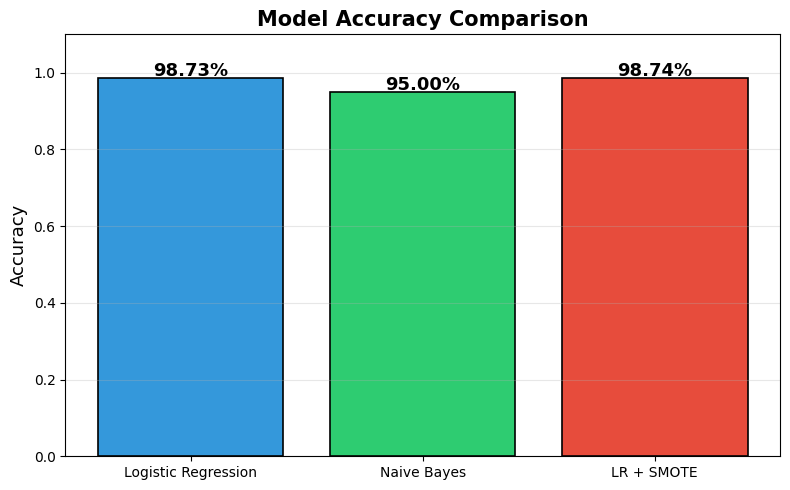

In [ ]:
print(" MODEL COMPARISON")
print(f"  1. Logistic Regression:          {accuracy_lr:.4f} ({accuracy_lr:.1%})")
print(f"  2. Naive Bayes:                  {accuracy_nb:.4f} ({accuracy_nb:.1%})")
print(f"  3. Logistic Regression + SMOTE:  {accuracy_smote:.4f} ({accuracy_smote:.1%})")

# Find the best
accuracies = {
    'Logistic Regression': accuracy_lr,
    'Naive Bayes': accuracy_nb,
    'LR + SMOTE': accuracy_smote,
}
best_name = max(accuracies, key=accuracies.get)
# max() with key=accuracies.get finds the key with the highest value
print(f"\n   Best model: {best_name} ({accuracies[best_name]:.1%})")

# ── Bar chart comparison ──
fig, ax = plt.subplots(figsize=(8, 5))

model_names = list(accuracies.keys())
model_scores = list(accuracies.values())
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(model_names, model_scores, color=colors, edgecolor='black', linewidth=1.2)

# Add accuracy labels on top
for bar, score in zip(bars, model_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # Center of the bar
        bar.get_height() + 0.005,              # Slightly above the bar
        f'{score:.2%}',
        ha='center', fontsize=13, fontweight='bold',
    )

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

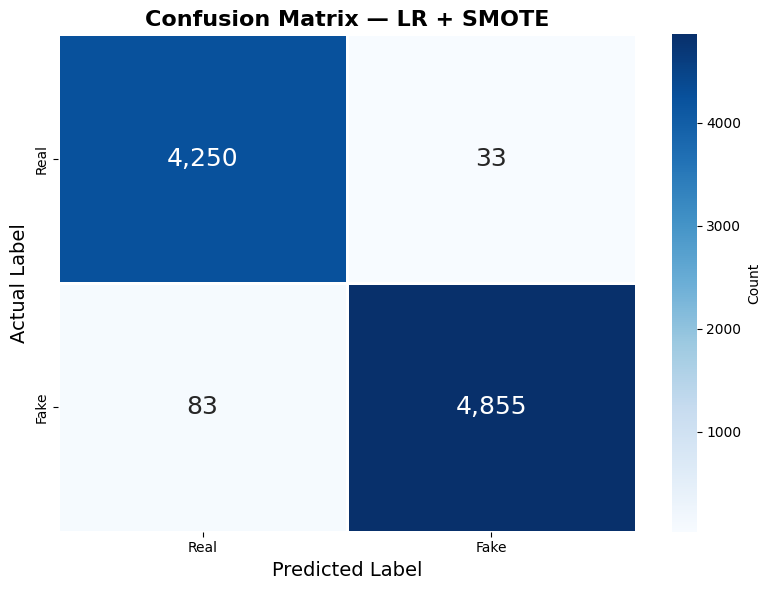


 Detailed Breakdown:
   True Negatives  (Real → Real):  4,250  (46.1%)
   True Positives  (Fake → Fake):  4,855  (52.7%)
   False Positives (Real → Fake):  33  (0.4%) — false alarms
   False Negatives (Fake → Real):  83  (0.9%) — missed fakes

  Total correct: 9,105 / 9,221 (98.7%)


In [ ]:
# Use the best performing model's predictions
# (we'll use LR + SMOTE but you can change this)
best_preds = y_pred_smote
best_model_label = "LR + SMOTE"

cm = confusion_matrix(y_test, best_preds)
# Returns a 2×2 matrix:
#
#                  Predicted Real    Predicted Fake
# Actually Real  [ True Negatives,  False Positives ]
# Actually Fake  [ False Negatives, True Positives  ]
#
# True Negative  (TN) = Article IS real, model said real     ✅ Correct!
# True Positive  (TP) = Article IS fake, model said fake     ✅ Correct!
# False Positive (FP) = Article IS real, model said fake     ❌ False alarm
# False Negative (FN) = Article IS fake, model said real     ❌ Missed it!

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,                                    # The 2×2 matrix
    annot=True,                            # Show numbers inside cells
    fmt=',d',                              # Format: integer with commas
    cmap='Blues',                           # Color scheme
    xticklabels=['Real', 'Fake'],          # X-axis labels
    yticklabels=['Real', 'Fake'],          # Y-axis labels
    ax=ax,                                 # Which chart to draw on
    annot_kws={'size': 18},                # Font size of numbers
    linewidths=2,                          # Line thickness between cells
    linecolor='white',                     # Line color
    cbar_kws={'label': 'Count'},           # Color bar label
)

ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('Actual Label', fontsize=14)
ax.set_title(f'Confusion Matrix — {best_model_label}', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Print interpretation ──
tn, fp, fn, tp = cm.ravel()
# .ravel() flattens [[TN, FP], [FN, TP]] into [TN, FP, FN, TP]
total = tn + fp + fn + tp

print(f"\n Detailed Breakdown:")
print(f"   True Negatives  (Real → Real):  {tn:,}  ({tn/total:.1%})")
print(f"   True Positives  (Fake → Fake):  {tp:,}  ({tp/total:.1%})")
print(f"   False Positives (Real → Fake):  {fp:,}  ({fp/total:.1%}) — false alarms")
print(f"   False Negatives (Fake → Real):  {fn:,}  ({fn/total:.1%}) — missed fakes")
print(f"\n  Total correct: {tn + tp:,} / {total:,} ({(tn+tp)/total:.1%})")

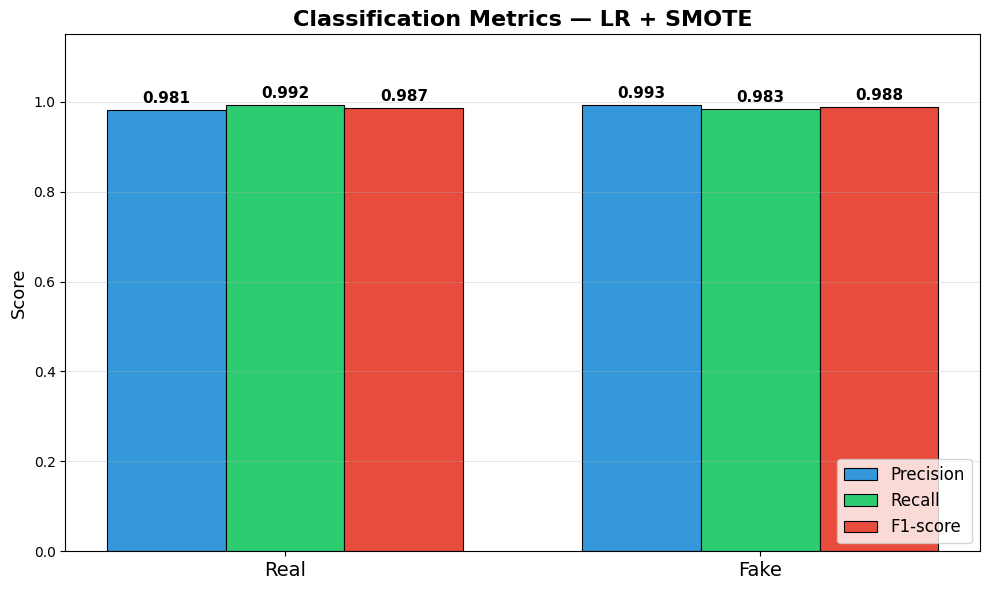

In [ ]:
report = classification_report(
    y_test, best_preds,
    target_names=['Real', 'Fake'],
    output_dict=True,   # Return as dictionary (not string) so we can plot it
)

classes = ['Real', 'Fake']
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(classes))   # [0, 1] — x positions for the class groups
width = 0.25                    # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']  # Blue, Green, Red

for i, metric in enumerate(metrics):
    # For each metric, create a group of bars
    values = [report[cls][metric] for cls in classes]
    # Gets [report['Real']['precision'], report['Fake']['precision']]

    bars = ax.bar(
        x + i * width,    # Offset each bar group:
                           # precision at x+0, recall at x+0.25, f1 at x+0.5
        values,
        width,
        label=metric.capitalize(),   # "precision" → "Precision" for the legend
        color=colors[i],
        edgecolor='black',
        linewidth=0.8,
    )
    # Add value labels on top of each bar
    ax.bar_label(bars, fmt='%.3f', fontsize=11, fontweight='bold', padding=3)
    # fmt='%.3f' → show 3 decimal places (e.g., 0.943)

ax.set_xticks(x + width)          # Center tick marks under each group
ax.set_xticklabels(classes, fontsize=14)
ax.set_ylim(0, 1.15)              # Room for labels above bars
ax.set_ylabel('Score', fontsize=13)
ax.set_title(f'Classification Metrics — {best_model_label}',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

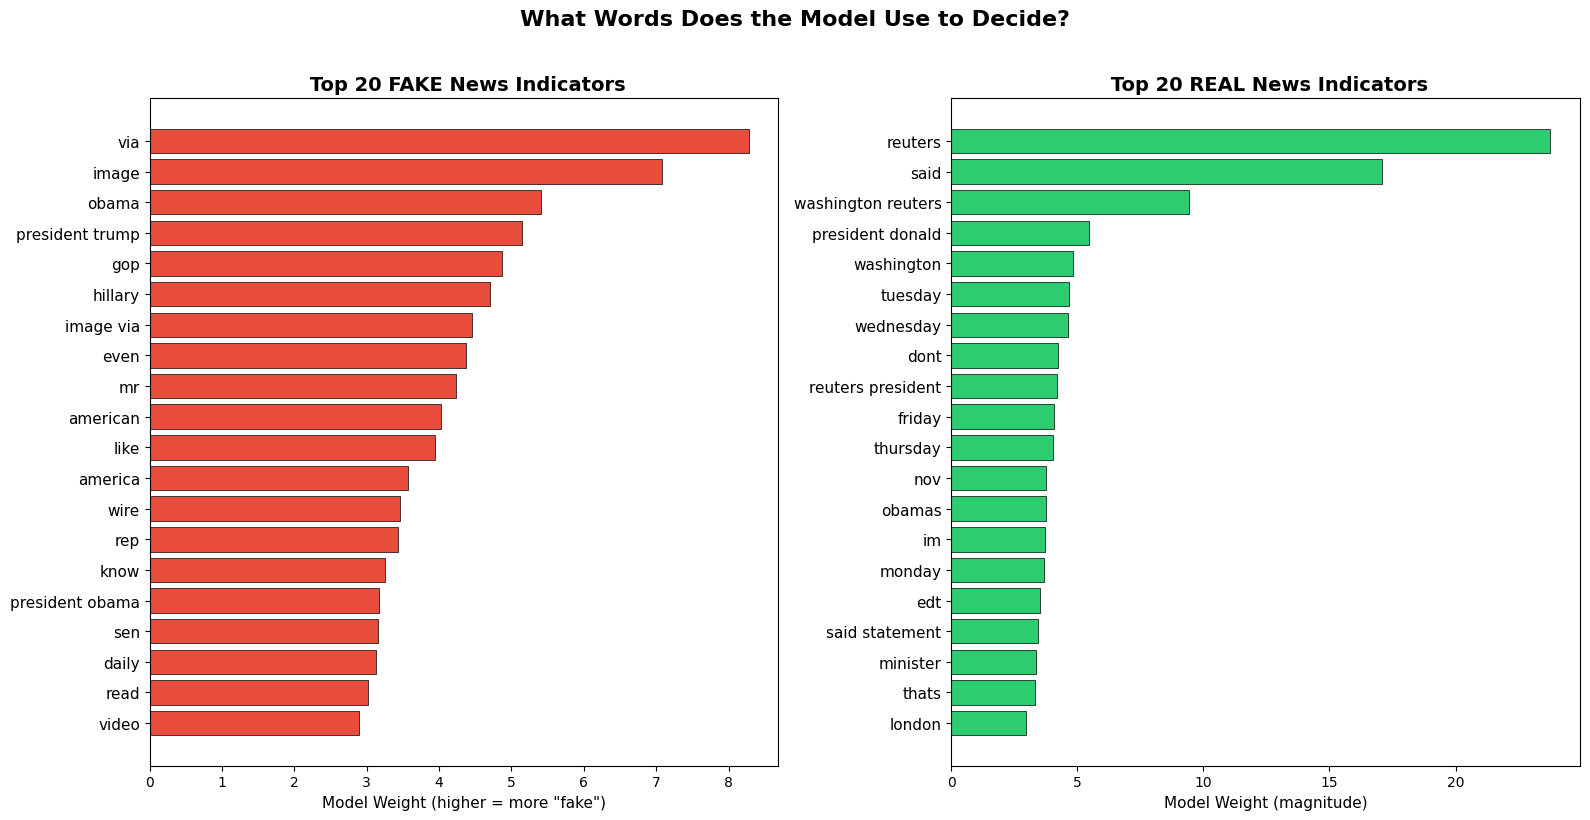

 This is called MODEL INTERPRETABILITY — you can explain WHY
   the model made a decision. Very important in real-world AI!


In [ ]:
# ═══ WHAT ARE WE DOING? ═══
# The Logistic Regression model learned a weight for each word.
# Positive weight → word suggests FAKE
# Negative weight → word suggests REAL
# Let's see which words have the highest/lowest weights!

feature_names = tfidf.get_feature_names_out()    # All 10,000 words
coefficients = model_lr_smote.coef_[0]           # Weight for each word
# .coef_ shape is (1, 10000) for binary classification
# [0] gets the single row of weights

# Create a DataFrame for easy sorting
word_importance = pd.DataFrame({
    'word': feature_names,
    'weight': coefficients,
})

# Get top 20 words for each direction
top_fake_words = word_importance.nlargest(20, 'weight')
# .nlargest(20, 'weight') → top 20 rows by highest 'weight' value
top_real_words = word_importance.nsmallest(20, 'weight')
# .nsmallest(20, 'weight') → top 20 rows by lowest 'weight' value

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Fake news indicator words
axes[0].barh(
    range(20),                              # Y positions: 0,1,2,...,19
    top_fake_words['weight'].values,        # Bar lengths
    color='#e74c3c',
    edgecolor='black',
    linewidth=0.5,
)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_fake_words['word'].values, fontsize=11)
axes[0].set_title(' Top 20 FAKE News Indicators', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Weight (higher = more "fake")', fontsize=11)
axes[0].invert_yaxis()   # Put highest weight at the TOP

# Real news indicator words
axes[1].barh(
    range(20),
    abs(top_real_words['weight'].values),    # Use absolute value for bar length
    color='#2ecc71',
    edgecolor='black',
    linewidth=0.5,
)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_real_words['word'].values, fontsize=11)
axes[1].set_title(' Top 20 REAL News Indicators', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model Weight (magnitude)', fontsize=11)
axes[1].invert_yaxis()

plt.suptitle('What Words Does the Model Use to Decide?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" This is called MODEL INTERPRETABILITY — you can explain WHY")
print("   the model made a decision. Very important in real-world AI!")

In [ ]:
# ═══ WHAT IS VADER? ═══
# VADER = Valence Aware Dictionary and sEntiment Reasoner
# A rule-based sentiment analyzer specifically tuned for SOCIAL MEDIA
#
# It understands:
#   "I love this!"         → positive (compound ≈ +0.7)
#   "This is terrible"     → negative (compound ≈ -0.5)
#   "The meeting is at 3pm" → neutral  (compound ≈ 0.0)
#   "AMAZING!!!"           → very positive (caps + !!! boost the score)
#   "not good"             → negative (handles negation)
#
# It returns 4 scores for each text:
#   pos:      proportion of text that is positive (0 to 1)
#   neg:      proportion that is negative (0 to 1)
#   neu:      proportion that is neutral (0 to 1)
#   compound: overall score from -1 (most negative) to +1 (most positive)

analyzer = SentimentIntensityAnalyzer()

# ── Quick demo ──
demo_texts = [
    "This is a wonderful and amazing achievement for humanity!",
    "The unemployment rate rose by 0.3 percent in January.",
    "SHOCKING!!! They are LYING to ALL of us!!! WAKE UP!!!",
]

print("=== VADER Sentiment Demo ===\n")
for text in demo_texts:
    scores = analyzer.polarity_scores(text)
    print(f"Text: \"{text}\"")
    print(f"  Positive: {scores['pos']:.3f}  Negative: {scores['neg']:.3f}  "
          f"Neutral: {scores['neu']:.3f}  Compound: {scores['compound']:.3f}")
    print()

=== VADER Sentiment Demo ===

Text: "This is a wonderful and amazing achievement for humanity!"
  Positive: 0.527  Negative: 0.000  Neutral: 0.473  Compound: 0.831

Text: "The unemployment rate rose by 0.3 percent in January."
  Positive: 0.000  Negative: 0.266  Neutral: 0.734  Compound: -0.440

Text: "SHOCKING!!! They are LYING to ALL of us!!! WAKE UP!!!"
  Positive: 0.000  Negative: 0.522  Neutral: 0.478  Compound: -0.867



 Analyzing sentiment for all articles
 Sentiment analysis complete!

 Average Sentiment Scores by Label:
-------------------------------------------------------
          sentiment_compound  sentiment_pos  sentiment_neg  sentiment_neu
Real (0)              0.0696         0.0788         0.0738         0.8473
Fake (1)             -0.0763         0.0904         0.0933         0.8163


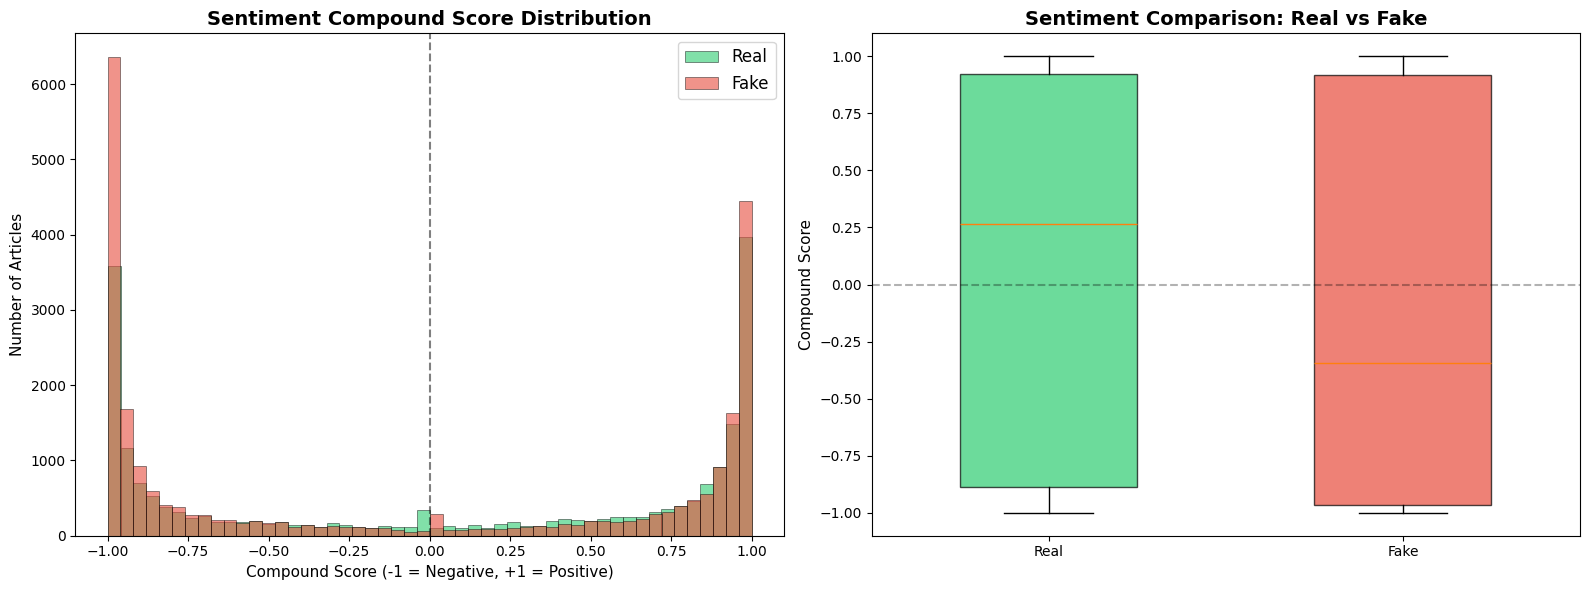


 Key Insight:
   Average sentiment for Real news: 0.0696
   Average sentiment for Fake news: -0.0763
   → Fake news tends to be MORE emotionally charged


In [ ]:
# ── Analyze sentiment of all articles (using ORIGINAL text, not cleaned) ──
# We use original text because VADER needs punctuation, caps, etc.
print(" Analyzing sentiment for all articles")

# Apply VADER to each article
sentiment_results = df['text'].apply(lambda text: analyzer.polarity_scores(str(text)))
# lambda text: ... is a mini function written in one line
# str(text) converts to string in case of NaN values
# Each result is a dictionary: {'neg': 0.1, 'neu': 0.7, 'pos': 0.2, 'compound': 0.3}

# Extract each score into its own column
df['sentiment_compound'] = sentiment_results.apply(lambda x: x['compound'])
df['sentiment_pos'] = sentiment_results.apply(lambda x: x['pos'])
df['sentiment_neg'] = sentiment_results.apply(lambda x: x['neg'])
df['sentiment_neu'] = sentiment_results.apply(lambda x: x['neu'])
# Each lambda grabs one key from the dictionary
# lambda x: x['compound'] is the same as writing:
#   def get_compound(x):
#       return x['compound']

print(" Sentiment analysis complete!")

# ── Compare average sentiment: Real vs Fake ──
print("\n Average Sentiment Scores by Label:")
print("-" * 55)
sentiment_summary = df.groupby('label')[['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu']].mean()
# .groupby('label')  → split data into two groups: label=0 (real) and label=1 (fake)
# [['col1','col2']]  → select only these columns
# .mean()            → calculate the average for each group
sentiment_summary.index = ['Real (0)', 'Fake (1)']   # Rename index for readability
print(sentiment_summary.round(4))
# .round(4) → round to 4 decimal places

# ── Visualize sentiment distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Histogram of compound scores ──
for label, color, name in [(0, '#2ecc71', 'Real'), (1, '#e74c3c', 'Fake')]:
    subset = df[df['label'] == label]['sentiment_compound']
    axes[0].hist(
        subset,
        bins=50,            # 50 bars across the range
        alpha=0.6,          # 60% opaque so overlapping areas are visible
        color=color,
        label=name,
        edgecolor='black',
        linewidth=0.5,
    )

axes[0].set_title('Sentiment Compound Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Compound Score (-1 = Negative, +1 = Positive)', fontsize=11)
axes[0].set_ylabel('Number of Articles', fontsize=11)
axes[0].legend(fontsize=12)
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Neutral')
# axvline draws a vertical line at x=0 (the neutral point)

# ── Chart 2: Box plot comparison ──
data_to_plot = [
    df[df['label'] == 0]['sentiment_compound'].values,  # Real scores
    df[df['label'] == 1]['sentiment_compound'].values,   # Fake scores
]
bp = axes[1].boxplot(
    data_to_plot,
    labels=['Real', 'Fake'],
    patch_artist=True,      # Fill the boxes with color
    widths=0.5,
)
# A box plot shows:
#   - The BOX: middle 50% of data (25th to 75th percentile)
#   - The LINE inside box: median (50th percentile)
#   - The WHISKERS: extend to 1.5× the box height
#   - The DOTS: outliers (extreme values beyond whiskers)

bp['boxes'][0].set_facecolor('#2ecc71')   # Green for Real
bp['boxes'][1].set_facecolor('#e74c3c')   # Red for Fake
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

axes[1].set_title('Sentiment Comparison: Real vs Fake', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Compound Score', fontsize=11)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
# axhline draws a horizontal line at y=0

plt.tight_layout()
plt.show()

# ── Key insight ──
real_mean = df[df['label'] == 0]['sentiment_compound'].mean()
fake_mean = df[df['label'] == 1]['sentiment_compound'].mean()
print(f"\n Key Insight:")
print(f"   Average sentiment for Real news: {real_mean:.4f}")
print(f"   Average sentiment for Fake news: {fake_mean:.4f}")
if abs(fake_mean) > abs(real_mean):
    print(f"   → Fake news tends to be MORE emotionally charged")
else:
    print(f"   → Both categories have similar emotional levels")

In [ ]:
# This function ties EVERYTHING together:
# 1. Takes raw text (what a user would type)
# 2. Cleans it (our clean_text function from earlier)
# 3. Converts to TF-IDF numbers (our fitted vectorizer)
# 4. Runs the ML model to get a prediction
# 5. Runs VADER sentiment analysis
# 6. Returns a full analysis report

def predict_fake_news(text):
    """
    Analyze a piece of text for fake news indicators.

    Parameters:
        text (str): Raw social media post or article text

    Returns:
        dict: Full analysis with prediction, probability, sentiment
    """

    # ── Step 1: Clean the text ──
    cleaned = clean_text(text)
    # Uses our function from Cell 9
    # "BREAKING!!! https://scam.com @user" → "breaking"

    # ── Step 2: Convert to TF-IDF numbers ──
    features = tfidf.transform([cleaned])
    # [cleaned] wraps the string in a list because .transform()
    # expects a LIST of texts, even if it's just one
    # Result: a 1×10000 sparse matrix (one row of numbers)

    # ── Step 3: Get model prediction ──
    prediction = model_lr_smote.predict(features)[0]
    # .predict() returns an array like [1]
    # [0] gets the single value: 1 (fake) or 0 (real)

    probabilities = model_lr_smote.predict_proba(features)[0]
    # .predict_proba() returns [[P(real), P(fake)]]
    # [0] gets [P(real), P(fake)]
    # Example: [0.15, 0.85] means 15% chance real, 85% chance fake

    # ── Step 4: Sentiment analysis ──
    sentiment = analyzer.polarity_scores(text)
    # Uses VADER on the ORIGINAL text (not cleaned)
    # because VADER needs punctuation, caps, etc.

    # ── Step 5: Determine bias level ──
    compound_abs = abs(sentiment['compound'])
    # abs() = absolute value: abs(-0.8) = 0.8, abs(0.3) = 0.3
    # We care about the MAGNITUDE of emotion, not the direction

    if compound_abs >= 0.6:
        bias_level = " HIGH"
        bias_explanation = "Strongly emotionally charged language detected."
    elif compound_abs >= 0.3:
        bias_level = " MODERATE"
        bias_explanation = "Some emotionally loaded language present."
    else:
        bias_level = " LOW"
        bias_explanation = "Language appears relatively neutral."

    # ── Step 6: Package everything into a result ──
    result = {
        'prediction': 'FAKE ' if prediction == 1 else 'REAL ',
        'fake_probability': probabilities[1],     # P(fake)
        'real_probability': probabilities[0],     # P(real)
        'confidence': max(probabilities),          # Higher of the two
        'sentiment_compound': sentiment['compound'],
        'sentiment_pos': sentiment['pos'],
        'sentiment_neg': sentiment['neg'],
        'sentiment_neu': sentiment['neu'],
        'bias_level': bias_level,
        'bias_explanation': bias_explanation,
        'cleaned_text': cleaned,
    }

    return result


def display_result(text):
    """Pretty-print the full analysis for a piece of text."""
    result = predict_fake_news(text)

    print("=" * 60)
    print(" FAKE NEWS ANALYSIS REPORT")
    print("=" * 60)

    # Show truncated input
    display_text = text[:120] + "..." if len(text) > 120 else text
    print(f"\n Input text:")
    print(f"   \"{display_text}\"")

    # Prediction
    print(f"\n{'─' * 40}")
    print(f"  Prediction:      {result['prediction']}")
    print(f" Fake probability: {result['fake_probability']:.1%}")
    print(f" Real probability: {result['real_probability']:.1%}")
    print(f" Confidence:       {result['confidence']:.1%}")

    # Sentiment
    print(f"\n{'─' * 40}")
    print(f" Sentiment Analysis:")
    print(f"   Positive:  {result['sentiment_pos']:.1%}")
    print(f"   Negative:  {result['sentiment_neg']:.1%}")
    print(f"   Neutral:   {result['sentiment_neu']:.1%}")
    print(f"   Compound:  {result['sentiment_compound']:.3f}")

    # Bias
    print(f"\n{'─' * 40}")
    print(f"  Bias Level: {result['bias_level']}")
    print(f"   {result['bias_explanation']}")
    print("=" * 60)



In [ ]:
# This creates an input box in Colab where you can type/paste any text

print("=" * 60)
print(" INTERACTIVE FAKE NEWS DETECTOR")
print("=" * 60)
print("Paste any social media post or news article below.")
print("Type 'quit' to stop.\n")

while True:
    # input() creates a text box in Colab and waits for you to type
    user_input = input(" Enter text to analyze (or 'quit'): ")

    if user_input.lower().strip() == 'quit':
        print("\n Goodbye!")
        break
    # .lower() converts to lowercase so "QUIT", "Quit", "quit" all work
    # .strip() removes leading/trailing spaces

    if not user_input.strip():
        print("  Please enter some text.\n")
        continue
    # continue = skip the rest of this loop iteration and go back to input()

    print()
    display_result(user_input)
    print()

 INTERACTIVE FAKE NEWS DETECTOR
Paste any social media post or news article below.
Type 'quit' to stop.

 Enter text to analyze (or 'quit'): quit

 Goodbye!


In [ ]:
import os
import pickle

# Create a folder for saved models
os.makedirs('models', exist_ok=True)
# exist_ok=True → don't crash if the folder already exists

# ── Save the TF-IDF vectorizer ──
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
# with open(...) as f:  → opens a file and auto-closes it when done
# 'wb'                  → "write binary" mode (pickle uses binary format)
# pickle.dump(obj, f)   → serializes the object and writes it to the file
#
# WHY SAVE THE VECTORIZER?
# The vectorizer learned which 10,000 words to use and their IDF scores
# during training. When you deploy the app, you need the EXACT SAME
# vectorizer, otherwise the model will get different numbers for the
# same text and make wrong predictions.

# ── Save the trained model ──
with open('models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model_lr_smote, f)

# ── Verify files were saved ──
for filename in ['models/tfidf_vectorizer.pkl', 'models/logistic_regression_model.pkl']:
    size = os.path.getsize(filename)   # File size in bytes
    size_mb = size / (1024 * 1024)     # Convert to megabytes
    print(f" Saved: {filename} ({size_mb:.2f} MB)")

# ── How to load them later (in your Streamlit app) ──
print("\n" + "=" * 55)
print(" TO LOAD THESE IN YOUR APP, USE THIS CODE:")
print("=" * 55)
print("""
import pickle

with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
    # 'rb' = "read binary" (opposite of 'wb')

with open('models/logistic_regression_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Now you can use them:
# features = tfidf.transform([cleaned_text])
# prediction = model.predict(features)
""")

In [ ]:
from google.colab import files

# This will trigger a download in your browser
files.download('models/tfidf_vectorizer.pkl')
files.download('models/logistic_regression_model.pkl')

print(" Check your browser's Downloads folder!")
print("   You'll need these two files for the Streamlit app.")

In [ ]:
!pip install transformers datasets accelerate -q

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset


In [ ]:
# ═══ IMPORTANT DIFFERENCE FROM BASELINE MODEL ═══
# For TF-IDF + Logistic Regression, we CLEANED the text first.
# For BERT, we use the RAW ORIGINAL text because:
# 1. BERT has its own tokenizer (WordPiece) that handles everything
# 2. BERT can learn from punctuation, capitalization, etc.
# 3. Cleaning would REMOVE useful information from BERT

# ── Sample a smaller subset ──
# Full dataset (44,000) would take hours to train on BERT.
# We'll use 5,000 for a quick demo. Increase for better results.
SAMPLE_SIZE = 5000

df_bert = df[['text', 'label']].copy()
# .copy() creates an independent copy so we don't modify the original df

# Make sure text is string and not empty
df_bert['text'] = df_bert['text'].astype(str)
df_bert = df_bert[df_bert['text'].str.strip() != '']

# Sample
df_bert = df_bert.sample(n=min(SAMPLE_SIZE, len(df_bert)), random_state=42)
print(f"BERT dataset size: {len(df_bert):,} articles")
print(f"Label distribution:\n{df_bert['label'].value_counts()}")

# ── Split into train/test ──
train_df, test_df = train_test_split(
    df_bert,
    test_size=0.2,
    random_state=42,
    stratify=df_bert['label'],
)

print(f"\nTraining: {len(train_df):,}")
print(f"Testing:  {len(test_df):,}")

# ── Convert to Hugging Face Dataset format ──
# The Trainer API expects this specific format, not pandas DataFrames
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
# .reset_index(drop=True) re-numbers rows 0,1,2,...
# Without this, the Dataset might have gaps in row numbers (e.g., row 5, 12, 38...)

print("\n Data prepared for BERT!")

BERT dataset size: 5,000 articles
Label distribution:
label
1    2694
0    2306
Name: count, dtype: int64

Training: 4,000
Testing:  1,000

 Data prepared for BERT!


In [ ]:
# ── Load the mBERT tokenizer ──
MODEL_NAME = 'bert-base-multilingual-cased'
# This model was pre-trained on Wikipedia in 104 LANGUAGES including:
# English, Filipino/Tagalog, Spanish, French, Chinese, Arabic, etc.
# "cased" means it distinguishes between "Apple" and "apple"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Downloads the tokenizer (~2 MB) — only happens once

# ── Demo: How BERT tokenizes text ──
demo = "BREAKING: Scientists discover new vaccine for COVID-19!"
tokens = tokenizer.tokenize(demo)
token_ids = tokenizer.encode(demo)
print("=== BERT Tokenization Demo ===")
print(f"Original:  \"{demo}\"")
print(f"Tokens:    {tokens}")
print(f"Token IDs: {token_ids}")
print()
# BERT uses "WordPiece" tokenization:
# - Common words stay whole: "new" → "new"
# - Rare words get split: "vaccine" → "va", "##cci", "##ne"
# - "##" means "continuation of previous word"
# - Each token maps to an ID (integer) in BERT's vocabulary

# ── Tokenize the entire dataset ──
def tokenize_function(examples):
    """Convert text to BERT input format."""
    return tokenizer(
        examples['text'],
        padding='max_length',    # Pad short texts with [PAD] tokens to max_length
                                 # BERT needs all inputs to be the SAME length
        truncation=True,         # Cut texts longer than max_length
        max_length=256,          # Maximum 256 tokens per article
                                 # BERT max is 512, but 256 is faster and usually enough
    )
    # Returns a dictionary with:
    # 'input_ids':      list of token IDs (integers)
    # 'attention_mask': list of 1s and 0s (1 = real token, 0 = padding)
    # 'token_type_ids': list of 0s (used for sentence pairs, not needed here)

print(" Tokenizing training data...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
# .map() applies the function to every example in the dataset
# batched=True processes multiple examples at once (much faster)

print(" Tokenizing test data...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

# ── Set format for PyTorch ──
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
# Tells the dataset to return PyTorch tensors (not Python lists)
# Only keep the columns BERT needs (drop the raw 'text' column)

print(f"\n Tokenization complete!")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Testing samples:  {len(test_dataset):,}")
print(f"   Each sample has: input_ids (256 tokens) + attention_mask (256 values) + label")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== BERT Tokenization Demo ===
Original:  "BREAKING: Scientists discover new vaccine for COVID-19!"
Tokens:    ['BR', '##EA', '##KI', '##NG', ':', 'Scientists', 'discover', 'new', 'va', '##cci', '##ne', 'for', 'CO', '##VI', '##D', '-', '19', '!']
Token IDs: [101, 49351, 36789, 59879, 34065, 131, 106232, 78599, 10751, 10321, 28217, 10238, 10142, 32992, 90939, 11490, 118, 10270, 106, 102]

 Tokenizing training data...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

 Tokenizing test data...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


 Tokenization complete!
   Training samples: 4,000
   Testing samples:  1,000
   Each sample has: input_ids (256 tokens) + attention_mask (256 values) + label


In [ ]:
import numpy as np
import torch

MODEL_NAME = 'bert-base-multilingual-cased'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load pre-trained mBERT + add classification layer ──
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,     # Binary classification: Real (0) vs Fake (1)
)
# This downloads the FULL mBERT model (~700 MB)
# It's a neural network with ~110 million parameters
# Pre-trained on Wikipedia text in 104 languages
# .from_pretrained() adds a small classification "head" on top:
#   BERT (110M params) → Linear layer (768 → 2) → [Real, Fake]

# ── Define evaluation metrics ──
from sklearn.metrics import accuracy_score as acc_fn, f1_score

def compute_metrics(eval_pred):
    """Called automatically by Trainer after each evaluation."""
    logits, labels = eval_pred
    # logits = raw model outputs (not probabilities yet)
    # Shape: (num_samples, 2) — one score for Real, one for Fake

    predictions = np.argmax(logits, axis=-1)
    # np.argmax finds the INDEX of the highest value
    # [0.3, 0.7] → argmax = 1 (Fake)
    # [0.9, 0.1] → argmax = 0 (Real)
    # axis=-1 means "along the last dimension" (across the 2 classes)

    return {
        'accuracy': acc_fn(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted'),
    }

# ── Configure training ──
training_args = TrainingArguments(
    output_dir='./bert_results',           # Save checkpoints here
    num_train_epochs=3,                    # Go through ALL training data 3 times
                                           # Each pass = 1 "epoch"
                                           # More epochs = more learning (but risk overfitting)

    per_device_train_batch_size=16,        # Process 16 articles at a time during training
                                           # Higher = faster but needs more GPU memory
                                           # If you get "CUDA out of memory", reduce to 8

    per_device_eval_batch_size=32,         # Process 32 articles at a time during evaluation
                                           # Can be higher than train because no gradients stored

    warmup_steps=100,                      # For the first 100 steps, slowly increase learning rate
                                           # Prevents the model from making wild changes early on

    weight_decay=0.01,                     # Regularization: slightly penalize large weights
                                           # Prevents overfitting (memorizing training data)

    logging_steps=50,                      # Print loss every 50 steps
    eval_strategy='epoch',                 # Run evaluation after each epoch
    save_strategy='epoch',                 # Save a checkpoint after each epoch
    load_best_model_at_end=True,           # After all epochs, load the best-performing one
    report_to='none',                      # Don't send logs to external services
)

# ── Create Trainer and train ──
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)
# The Trainer handles everything:
# - Moving data to GPU
# - Forward pass (predictions)
# - Loss calculation
# - Backward pass (gradient computation)
# - Weight updates (optimization)
# - Logging and saving

print(" Starting BERT fine-tuning")


trainer.train()

print("\n BERT training complete!")

# ── Evaluate ──
results = trainer.evaluate()
print(f"\n BERT Final Results:")
print(f"   Accuracy: {results['eval_accuracy']:.4f} ({results['eval_accuracy']:.1%})")
print(f"   F1 Score: {results['eval_f1']:.4f} ({results['eval_f1']:.1%})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Starting BERT fine-tuning...
   This takes ~10-20 minutes on a T4 GPU
   You'll see progress bars and loss values below



Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
def predict_with_bert(text):
    """
    Predict fake news using the fine-tuned BERT model.
    Works with ANY language BERT was trained on (104 languages).
    """
    # Tokenize the input
    inputs = tokenizer(
        text,
        return_tensors='pt',      # Return PyTorch tensors
        truncation=True,
        max_length=256,
        padding=True,
    )

    # Move everything to GPU (if available)
    inputs = {key: val.to(device) for key, val in inputs.items()}
    # This is a dictionary comprehension:
    # For each key-value pair in inputs, move the tensor to the GPU
    # Same as:
    #   inputs['input_ids'] = inputs['input_ids'].to('cuda')
    #   inputs['attention_mask'] = inputs['attention_mask'].to('cuda')

    model_bert.to(device)
    model_bert.eval()
    # .eval() switches the model to evaluation mode:
    # - Disables dropout (random neuron deactivation used during training)
    # - Disables batch normalization updates
    # Without this, predictions would be slightly random each time!

    with torch.no_grad():
        # torch.no_grad() tells PyTorch: "I'm not training, don't track
        # gradients." This saves GPU memory and makes prediction faster.
        outputs = model_bert(**inputs)
        # **inputs unpacks the dictionary:
        # model_bert(input_ids=..., attention_mask=...)

        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        # softmax converts raw scores (logits) to probabilities
        # that sum to 1.0
        # Example: logits [2.1, -0.5] → softmax [0.93, 0.07]

    fake_prob = probabilities[0][1].item()
    real_prob = probabilities[0][0].item()
    # [0] = first (only) sample in the batch
    # [1] = fake class probability
    # .item() converts a PyTorch tensor to a plain Python number

    label = 'FAKE ❌' if fake_prob > 0.5 else 'REAL ✅'

    # Pretty print
    print(f" Text: \"{text[:100]}{'...' if len(text) > 100 else ''}\"")
    print(f" BERT says:     {label}")
    print(f"   Fake prob:     {fake_prob:.1%}")
    print(f"   Real prob:     {real_prob:.1%}")
    print(f"   Confidence:    {max(fake_prob, real_prob):.1%}")
    print()

    return fake_prob

FINAL MODEL COMPARISON

  Logistic Regression       98.73%  ███████████████████████████████████████
  Naive Bayes               95.00%  ██████████████████████████████████████
  LR + SMOTE                98.74%  ███████████████████████████████████████

   Winner: LR + SMOTE (98.74%)


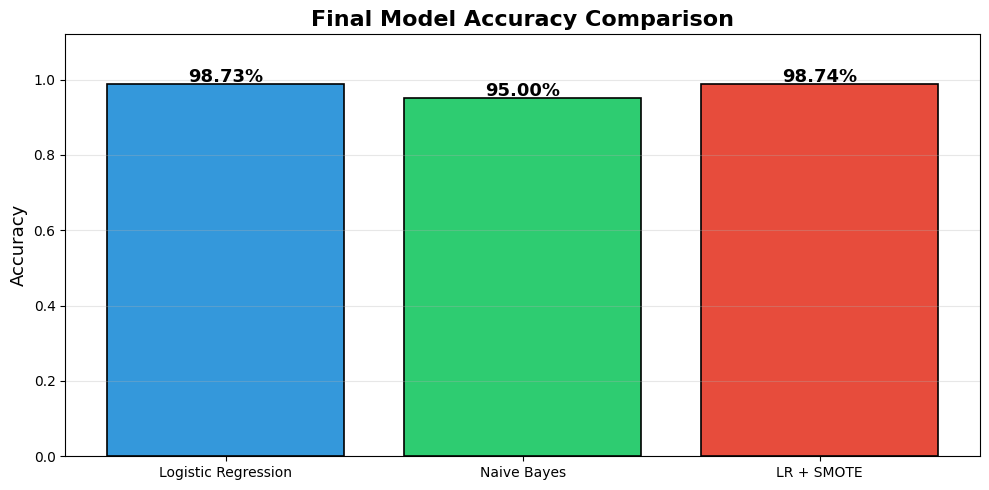

In [ ]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

all_models = {
    'Logistic Regression': accuracy_lr,
    'Naive Bayes': accuracy_nb,
    'LR + SMOTE': accuracy_smote,
}

# Add BERT if it was trained
if 'results' in dir():
    all_models['mBERT (fine-tuned)'] = results['eval_accuracy']

print()
for name, acc in all_models.items():
    bar = '█' * int(acc * 40)    # Visual bar (40 chars max)
    print(f"  {name:25s} {acc:.2%}  {bar}")
    # :25s = left-align in a 25-character space (so bars line up)

best_name = max(all_models, key=all_models.get)
print(f"\n   Winner: {best_name} ({all_models[best_name]:.2%})")

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))

names = list(all_models.keys())
scores = list(all_models.values())
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'][:len(names)]

bars = ax.bar(names, scores, color=colors, edgecolor='black', linewidth=1.2)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.2%}',
        ha='center', fontsize=13, fontweight='bold',
    )

ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Final Model Accuracy Comparison', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()